(robust_permanent_income)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 稳健永久收入与定价

```{contents} 目录
:depth: 2
```

除了 Anaconda 中已有的库之外，本讲座还需要以下库：

In [1]:
!pip install --upgrade quantecon

## 概述

本讲座研究 {cite:t}`HST_1999` 的模型。

这篇论文提出了一个简单的问题，却带来了令人惊讶的结论。

当一个经典的永久收入消费者不再信任其收入的单一概率模型，而是*担心其模型可能被误设*，并希望自己的决策在一*族*相近的模型上都能表现良好时，会发生什么？

这样的消费者被称为**稳健**决策者。

核心发现如下：

* 对稳健性的偏好隐藏在普通永久收入模型的数量含义之中。
* 稳健性与风险敏感性是对*同一*决策规则的两种解读，两者都由单一参数 $\sigma$ 支配。
* 对*微小*程度的模型误设的担忧可以表现为*巨大*的基于市场的风险厌恶度量。
* 仅凭消费和储蓄数据无法识别稳健性参数：该模型与一个贴现因子更低的标准永久收入模型是**观测等价**的。
* 但资产价格，特别是**风险的市场价格**，*可以*用来确定稳健性。

我们将学习

* 风险敏感的递归偏好以及算子 $\mathcal{R}_t$
* 一个恶意的"第二个体"如何通过双人零和博弈来实现对稳健性的偏好
* 稳健性与 {cite:t}`GilboaSchmeidler:1989` 和 {cite:t}`EpsteinWang1994` 意义下的**奈特不确定性**之间的联系
* 一个我们将用数值方法重现的**观测等价**结果
* 对条件均值的一个微小的最坏情形扭曲如何几乎一对一地转化为风险的市场价格

本讲座建立在 {doc}`perm_income`、{doc}`perm_income_cons` 和 {doc}`lqcontrol` 中的思想之上。

这里的稳健性机制在 {cite:t}`HansenSargent2008` 中以专著篇幅进行了发展，在 {cite:t}`AHS_2003` 中得到了扩展，并在 {cite:t}`BHS_2009` 中通过检测误差概率进行了重新诠释。

让我们从一些导入开始。

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from scipy.stats import norm
import quantecon as qe
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n

## 风险敏感的递归偏好

该理论建立在一个递归的线性二次型优化问题之上，但在延续效用如何聚合方面有一个转折。

状态按如下方式演化

$$
x_{t+1} = A x_t + B i_t + C w_{t+1},
$$ (eq:hst_lom)

其中 $i_t$ 是控制向量，$x_t$ 是状态向量，$w_{t+1}$ 是一个 IID 高斯向量，满足 $\mathbb{E} w_{t+1} = 0$ 和 $\mathbb{E} w_{t+1} w_{t+1}^\top = I$。

单期回报为

$$
u(i_t, x_t) = -i_t^\top Q i_t - x_t^\top R x_t,
$$ (eq:hst_return)

其中 $Q$ 正定，$R$ 半正定。

参照 {cite:t}`Epstein_Zin1989`、{cite:t}`Weil_1989` 和 {cite:t}`hansen1995discounted`，跨期偏好由如下递归导出

$$
U_t = u(i_t, x_t) + \beta \, \mathcal{R}_t(U_{t+1}),
$$ (eq:hst_recursion)

其中**风险敏感算子**为

$$
\mathcal{R}_t(U_{t+1}) \equiv \frac{2}{\sigma} \log \mathbb{E}\!\left[ \exp\!\left( \frac{\sigma U_{t+1}}{2} \right) \Big| J_t \right].
$$ (eq:hst_R)

这里 $J_t$ 是在 $t$ 时刻可用的信息。

当 $\sigma = 0$ 时，我们设 $\mathcal{R}_t \equiv \mathbb{E}(\,\cdot \mid J_t)$，从而回到通常的冯·诺依曼-摩根斯坦、状态可加的设定。

当 $\sigma \neq 0$ 时，算子 $\mathcal{R}_t$ 在 $u$ 的曲率所带来的风险调整*之上*应用了一个额外的风险调整。

$\sigma < 0$ 的取值对应于比冯·诺依曼-摩根斯坦基准*更强*的风险厌恶，这也是整篇论文所研究的情形。

```{note}
{eq}`eq:hst_R` 中的效用指数形式源自由 {cite:t}`Jacobson_73` 开创、并由 {cite:t}`Whittle_1981` 和 {cite:t}`Whittle_1990` 扩展的*风险敏感控制*文献。

{cite:t}`HST_1999` 将其重新诠释为对*稳健性的偏好*这一经济学含义。
```

### 高斯不确定性下的算子

当延续效用服从高斯分布时，算子 $\mathcal{R}_t$ 具有清晰的闭式表达。

设在给定 $J_t$ 的条件下 $U_{t+1} \sim N(\mu, s^2)$。利用高斯矩生成函数 $\mathbb{E}[\exp(a U_{t+1})] = \exp(a\mu + \tfrac{1}{2}a^2 s^2)$ 并取 $a = \sigma/2$，

$$
\mathcal{R}_t(U_{t+1})
= \frac{2}{\sigma} \log \mathbb{E}\!\left[ \exp\!\left( \frac{\sigma U_{t+1}}{2} \right) \Big| J_t \right]
= \frac{2}{\sigma}\left( \frac{\sigma}{2}\mu + \frac{\sigma^2}{8} s^2 \right)
= \mu + \frac{\sigma}{4} s^2.
$$ (eq:hst_R_gauss)

对于 $\sigma < 0$，这个值*低于*条件均值 $\mu$：决策者以*悲观*的方式评估不确定的前景，而惩罚随条件方差 $s^2$ 增大。

这一确定性等价值有一个富有启发性的分解。

{eq}`eq:hst_R` 中的期望通过 $\exp(\sigma U_{t+1}/2)$ 对结果重新加权；对于高斯分布，这种**指数倾斜**产生了一个新的正态密度，其方差*仍为* $s^2$，但均值移动到了 $\mu + \frac{\sigma}{2} s^2$。

算子值 $\mu + \frac{\sigma}{4} s^2$ 恰好位于原均值 $\mu$ 与这个最坏情形均值之间的*正中*：它等于最坏情形的期望效用 $\mu + \frac{\sigma}{2}s^2$ *加上*相对熵惩罚 $-\frac{\sigma}{4}s^2$，后者约束着扭曲。

```{note}
这两个系数描述的是不同的对象。

$U_{t+1}$ 的**最坏情形均值**移动了 $\frac{\sigma}{2}s^2$，而**算子值**（确定性等价值）移动了 $\frac{\sigma}{4}s^2$。

两者都是正确的；$\mathcal{R}_t$ 较小的移动反映了恶意个体为扭曲所付出的熵代价。

{eq}`eq:hst_R_gauss` 的一个完整推导在 {ref}`hst_ex1` 中给出。
```

让我们将这两个事实可视化，左边是确定性等价值，右边是延续效用的最坏情形（倾斜后的）密度。

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


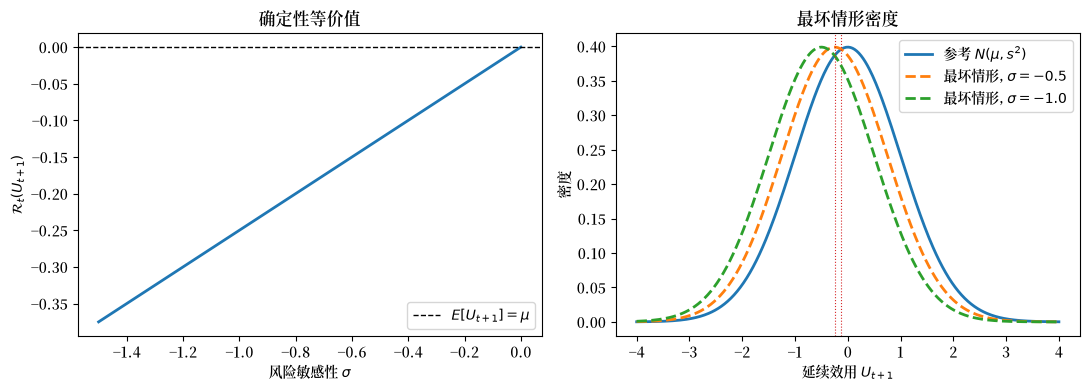

In [3]:
μ, s = 0.0, 1.0           # 延续效用的条件均值和标准差

def R_operator(μ, s, σ):
    "针对高斯分布 U ~ N(μ, s^2) 的风险敏感算子。"
    if σ == 0:
        return μ
    return μ + σ * s**2 / 4

σ_vals = np.linspace(-1.5, 0.0, 200)
R_vals = [R_operator(μ, s, sg) for sg in σ_vals]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(σ_vals, R_vals, lw=2)
axes[0].axhline(μ, color='k', ls='--', lw=1, label=r'$E[U_{t+1}]=\mu$')
axes[0].set_xlabel(r'风险敏感性 $\sigma$')
axes[0].set_ylabel(r'$\mathcal{R}_t(U_{t+1})$')
axes[0].set_title('确定性等价值')
axes[0].legend()

# 倾斜后的密度
grid = np.linspace(μ - 4*s, μ + 4*s, 400)
axes[1].plot(grid, norm.pdf(grid, μ, s), lw=2,
             label=r'参考 $N(\mu, s^2)$')
for σ in [-0.5, -1.0]:
    shift = σ * s**2 / 2     # U_{t+1} 的最坏情形均值移动
    axes[1].plot(grid, norm.pdf(grid, μ + shift, s), lw=2, ls='--',
                 label=f'最坏情形, $\\sigma={σ}$')
    axes[1].axvline(μ + σ * s**2 / 4, color='C3', lw=0.8, ls=':')
axes[1].set_xlabel(r'延续效用 $U_{t+1}$')
axes[1].set_ylabel('密度')
axes[1].set_title('最坏情形密度')
axes[1].legend()
fig.tight_layout()
plt.show()

左图展示了随着 $\sigma$ 变得更负，确定性等价值 $\mathcal{R}_t$ 滑落到均值之下。

右图展示了相应的延续效用的最坏情形密度：一个稳健的个体*表现得仿佛* $U_{t+1}$ 是从一个悲观地重新居中的分布（均值 $\mu + \frac{\sigma}{2}s^2$，虚线）中抽取的，而算子值 $\mathcal{R}_t = \mu + \frac{\sigma}{4}s^2$（点线）则位于它与参考均值 $\mu$ 之间的中点。

## 对稳健性的偏好

上面右图中的悲观倾斜不仅仅是一个类比。

{cite:t}`HST_1999` 表明，风险敏感问题是一个**双人零和博弈**的值函数。

在这个博弈中，一个个体选择控制 $\{i_t\}$，而第二个恶意的个体选择对冲击条件均值的扭曲 $\{v_t\}$。

扭曲后的运动规律为

$$
x_{t+1} = A x_t + B i_t + C (w_{t+1} + v_t).
$$ (eq:hst_distorted_lom)

最小化的个体希望将状态推向令人痛苦的方向，但受到对扭曲大小的惩罚的约束。

以 $-1/\sigma \geq 0$ 作为约束扭曲序列的约束的拉格朗日乘子，马尔可夫完美均衡具有值函数

$$
\tilde{W}(x) = \inf_v \sup_i \left\{ -i^\top Q i - x^\top R x + \beta \left[ -\frac{1}{\sigma} v^\top v + \mathbb{E}\,\tilde{W}(Ax + Bi + C(w + v)) \right] \right\}.
$$ (eq:hst_game)

因为 $\sigma < 0$ 使得 $-1/\sigma > 0$，所以 $-\frac{1}{\sigma}v^\top v$ 这一项*惩罚*恶意个体的大扭曲。

较小的 $|1/\sigma|$（更负的 $\sigma$）意味着更便宜的扭曲预算，因而个体所防范的模型族更大，反映出*更强*的对稳健性的偏好。

这正是 {cite:t}`GilboaSchmeidler:1989` 的最大-最小期望效用结构：个体的"名义模型"设 $v_t = 0$，但他们考虑由 $\{v_t\}$ 索引的整整一族替代模型，并针对最坏情形采取行动。

参照 {cite:t}`EpsteinWang1994`，所隐含的概率测度的非唯一性是**奈特不确定性**的一种形式。

稳健问题与风险敏感问题共享同一个值函数矩阵 $\Omega$ 和同一个决策规则 $i_t = -F x_t$；它们仅在解读上有所不同。

## 永久收入经济

现在我们特殊化到永久收入模型的一个习惯持续性版本。

一个规划者通过服务流 $\{s_t\}$ 并使用如下递归来对消费流 $\{c_t\}$ 排序

$$
U_t = -(s_t - b_t)^2 + \beta\, \mathcal{R}_t(U_{t+1}),
$$ (eq:hst_pi_pref)

其中 $\{b_t\}$ 是一个外生的偏好（极乐点）冲击。

服务通过家庭技术从消费中产生

$$
s_t = (1 + \lambda) c_t - \lambda h_{t-1},
$$ (eq:hst_services)

$$
h_t = \delta_h h_{t-1} + (1 - \delta_h) c_t,
$$ (eq:hst_habit)

其中 $\lambda > 0$ 且 $\delta_h \in (0, 1)$。

这里 $h_t$ 是当前和过去消费的几何平均，因此 {eq}`eq:hst_services` 使服务*负向地*依赖于过去消费的加权平均，这就是**习惯持续性**。

存在一个线性生产技术

$$
c_t + i_t = \gamma k_{t-1} + d_t,
$$

且资本按 $k_t = \delta_k k_{t-1} + i_t$ 累积，其中 $\{d_t\}$ 是一个外生禀赋。

综合起来，

$$
c_t + k_t = (\delta_k + \gamma) k_{t-1} + d_t,
\qquad R \equiv \delta_k + \gamma,
$$ (eq:hst_budget)

因此 $R$ 是资本的总物理回报，在一个去中心化经济中它等于总的**无风险利率**。

禀赋冲击和偏好冲击由一个共同的线性状态驱动，

$$
z_{t+1} = A_{22} z_t + C_2 w_{t+1},
\qquad d_t = U_d z_t, \quad b_t = U_b z_t.
$$ (eq:hst_shocks)

整个经济是控制问题 {eq}`eq:hst_lom`–{eq}`eq:hst_recursion` 的一个特例：将 $h_{t-1}$、$k_{t-1}$ 和 $z_t$ 堆叠进状态 $x_t$，并令控制为 $i_t = s_t - b_t$。

### $\sigma = 0$ 基准与鞅

为了建立直觉，设 $\sigma = 0$ 并施加永久收入约束 $\beta R = 1$，正如 {cite:t}`Hall1978` 中所做的那样。

一阶条件随后表明，消费服务的边际效用是一个**鞅**，

$$
\mathbb{E}_t \, \mu_{c,t+1} = \mu_{c,t},
$$ (eq:hst_martingale)

并且 $\mu_{s,t}$ 继承了如下表示

$$
\mu_{s,t} = \mu_{s,t-1} + v^\top w_t
$$ (eq:hst_mu_rw)

其中 $v$ 为某个载荷向量。

方程 {eq}`eq:hst_martingale` 是经典的表述，即在 $\beta R = 1$ 下，消费只对*新信息*作出反应，因此它是一个随机游走。

这正是 {cite:t}`Hall1978` 和 {cite:t}`Campbell1987` 在美国总量数据上检验的结果。

标量

$$
\theta^2 \equiv v^\top v
$$

度量了边际效用鞅 {eq}`eq:hst_mu_rw` 的新息方差。

它将是我们下面所需的基准经济唯一的一个汇总统计量。

```{note}
在理性预期解读下，基准 $\sigma = 0$ 的永久收入模型*没有预防性储蓄*，正如 Zeldes 所强调的那样。

引入稳健性（$\sigma < 0$）重新激活了一个预防性动机：消费者防范冲击条件均值中的最坏情形误差。
```

## 观测等价

这是这篇论文的第一个重要结果。

```{prf:proposition} 观测等价
:label: prop:hst_oe

固定除 $\beta$ 和 $\sigma$ 之外的所有参数。假设 $\beta R = 1$。则存在 $\underline{\sigma} < 0$，使得当 $\sigma = 0$ 时最优的消费-投资计划*同样*对任何 $\sigma \in (\underline{\sigma}, 0)$ 都是最优的，前提是贴现因子被降低到一个随 $\sigma$ 直接变化的值 $\hat\beta(\sigma)$。
```

换言之：就*数量* $\{c_t, k_t\}$ 而言，稳健（$\sigma < 0$）的永久收入模型与贴现因子较小的标准（$\sigma = 0$）模型是无法区分的。

增强对稳健性的偏好会刺激一个预防性储蓄动机；降低 $\beta$ 会使储蓄变得不那么有吸引力；沿着某条特定的轨迹，这两种效应恰好相互抵消。

证明是构造性的，并给出了观测等价的 $(\sigma, \hat\beta)$ 对的显式轨迹。定义

$$
\Omega(\beta) = \frac{\beta - 1 + \sigma \theta^2 + \sqrt{(\beta - 1 + \sigma \theta^2)^2 + 4 \sigma \theta^2}}{-2 \sigma \theta^2},
$$ (eq:hst_Omega_scalar)

$$
\hat\zeta(\beta) = 1 + \frac{\theta^2 \sigma\, \Omega(\beta)}{1 - \sigma \theta^2 \Omega(\beta)} .
$$ (eq:hst_zeta)

等价贴现因子 $\hat\beta$ 解

$$
\hat\beta \, R \, \hat\zeta(\hat\beta) = 1.
$$ (eq:hst_betahat)

下界 $\underline{\sigma}$ 是 {eq}`eq:hst_Omega_scalar` 中的平方根保持为实数的最负的 $\sigma$。

让我们重现这条轨迹，它是 {cite:t}`HST_1999` 中图 1 的一个版本。

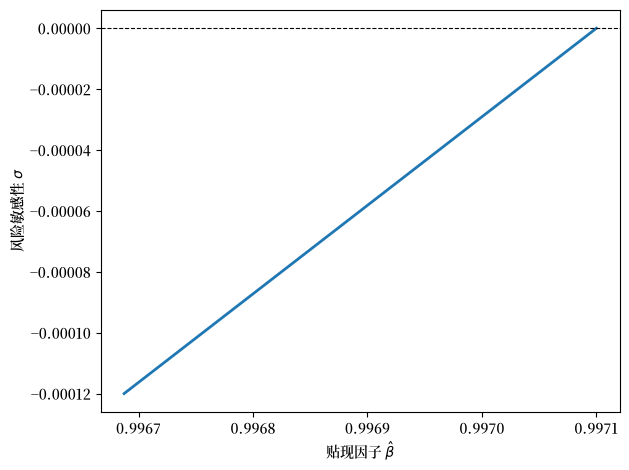

In [4]:
β_bench = 0.9971         # 基准贴现因子（年利率约 2.5%）
Rf = 1 / β_bench         # 由 β R = 1 确定的总无风险回报
θ2 = 0.01               # 边际效用新息的方差, v^T v

def Ω_scalar(β, σ, θ2):
    disc = (β - 1 + σ * θ2)**2 + 4 * σ * θ2
    if disc < 0:
        return np.nan        # 低于 σ 下界：无实数解
    return (β - 1 + σ * θ2 + np.sqrt(disc)) / (-2 * σ * θ2)

def ζ_hat(β, σ, θ2):
    Ω = Ω_scalar(β, σ, θ2)
    return 1 + (θ2 * σ * Ω) / (1 - σ * θ2 * Ω)

def β_hat(σ, θ2, Rf):
    "使 σ 与 σ=0 观测等价的贴现因子。"
    if σ == 0:
        return 1 / Rf
    f = lambda b: b * Rf * ζ_hat(b, σ, θ2) - 1
    return brentq(f, 0.95, 1 / Rf - 1e-12)

σ_vals = np.linspace(-1.2e-4, 0.0, 200)
β_vals = np.array([β_hat(sg, θ2, Rf) for sg in σ_vals])

fig, ax = plt.subplots()
ax.plot(β_vals, σ_vals, lw=2)
ax.set_xlabel(r'贴现因子 $\hat\beta$')
ax.set_ylabel(r'风险敏感性 $\sigma$')
ax.axhline(0, color='k', lw=0.8, ls='--')
fig.tight_layout()
plt.show()

这条曲线上的每一点都产生*完全相同*的消费和投资数据。

沿曲线向下移动（更负的 $\sigma$，即对稳健性更强的偏好）需要*更低*的贴现因子 $\hat\beta$ 才能保持数量不变。

这就是为什么仅凭消费和储蓄数据无法告诉我们消费者对模型误设的担忧程度。

## 估计

{cite:t}`HST_1999` 将观测等价结果转化为一种实证策略。

由于数量数据无法确定 $\sigma$，作者们首先估计模型的 $\sigma = 0$ 版本，*仅*以消费和投资为条件构建似然，然后利用 {prf:ref}`prop:hst_oe` 的轨迹描绘出与这些估计相符的 $(\sigma, \hat\beta)$ 对族。

资产价格（下一节）打破了这一僵局。

### 数据与似然

模型拟合到美国战后季度数据，1970 年第一季度至 1996 年第三季度。

* *消费*被度量为非耐用品加服务。
* *投资*被度量为耐用品加私人投资总额。

两个序列都用确定性增长因子 $1.0033^{t}$ 平减，因此模型拟合到*去趋势*的数据。

似然是高斯的，递归构建（卡尔曼滤波器），初始状态的不可观测部分使用 Hansen 和 Sargent 的方法进行估计。

### 设定

偏好冲击是一个常数，$b_t = \mu_b$，固定为 $\mu_b = 32$；回顾 {eq}`eq:hst_budget` 的讨论，$b_t$ 的*水平*不影响决策规则，只影响价格。

禀赋是一个*持续*成分和一个*暂时*成分之和，每个成分都是由正交冲击驱动的二阶自回归，

$$
(1 - \phi_1 L)(1 - \phi_2 L)\, d^{*}_t = c_{d^{*}}\, w^{d^{*}}_t,
$$ (eq:hst_dstar)

$$
(1 - \alpha_1 L)(1 - \alpha_2 L)\, \hat d_t = c_{\hat d}\, w^{\hat d}_t,
$$ (eq:hst_dhat)

其中 $d_t = \mu_d + d^{*}_t + \hat d_t$。

一个似然比较（从 AR(1) 到 AR(2) 有收益但再往后没有）促使作者们为暂时成分采用二阶设定。

支配内生动态的四个参数是 $(\gamma, \delta_k, \beta, \lambda)$。

折旧因子设为 $\delta_k = 0.975$，并施加永久收入约束 $\beta R = 1$（由无约束估计所证实），$\beta = 0.9971$，在增长调整后意味着 $2.5\%$ 的年实际利率。

带习惯持续性的最大似然估计如下重现，它是 {cite:t}`HST_1999` 中表 2 的一个版本。

| 参数 | 符号 | 估计值 |
|---|---|---|
| 贴现因子 | $\beta$ | 0.997 |
| 习惯折旧 | $\delta_h$ | 0.682 |
| 习惯权重 | $\lambda$ | 2.443 |
| 暂时 AR 根 | $\alpha_1, \alpha_2$ | 0.813, 0.189 |
| 持续 AR 根 | $\phi_1, \phi_2$ | 0.998, 0.704 |
| 禀赋均值 | $\mu_d$ | 13.710 |
| 暂时冲击尺度 | $c_{\hat d}$ | 0.155 |
| 持续冲击尺度 | $c_{d^{*}}$ | 0.108 |

最引人注目的单个估计是持续禀赋成分的自回归根 $\phi_1 = 0.998$，这个数字几乎与单位根无法区分。

### 脉冲响应与永久收入机制

冲击的持续性决定了消费对其反应的强度。

在永久收入逻辑下（$\beta R = 1$ 且，为清晰起见，*没有*习惯），消费在冲击时刻按财富变化的**年金价值**跳升，此后是一个鞅，

$$
\Delta c = \left(1 - \frac{1}{R}\right) \sum_{j \geq 0} R^{-j}\, \psi_j,
$$ (eq:hst_pi_mpc)

其中 $\psi_j = \partial d_{t+j} / \partial w_t$ 是禀赋自身的脉冲响应。

一个近乎永久的冲击具有很大的现值并使消费大幅移动；一个暂时冲击具有很小的现值并几乎不使其移动。

让我们计算禀赋响应 {eq}`eq:hst_dstar`–{eq}`eq:hst_dhat` 以及隐含的消费响应。

findfont: Failed to find font weight normal, now using 600.


持续冲击: 消费响应于 41% 的冲击
暂时冲击: 消费响应于 2% 的冲击


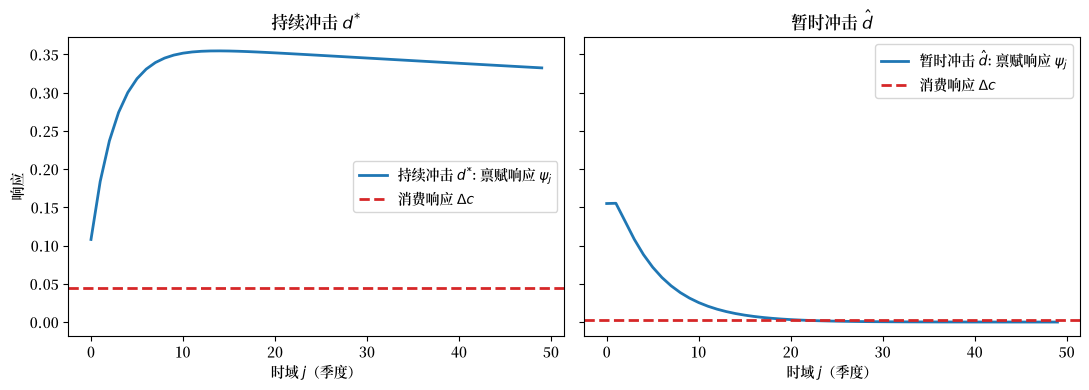

In [5]:
def ar2_irf(r1, r2, c, H):
    "(1 - r1 L)(1 - r2 L) x = c w 对单位 w 冲击的脉冲响应。"
    ψ = np.zeros(H)
    ψ[0] = c
    if H > 1:
        ψ[1] = (r1 + r2) * ψ[0]
    for j in range(2, H):
        ψ[j] = (r1 + r2) * ψ[j-1] - r1 * r2 * ψ[j-2]
    return ψ

H = 50
disc = Rf**(-np.arange(H))   # 来自上一个单元格的 Rf = 1/β

ψ_p = ar2_irf(0.998, 0.704, 0.108, H)         # 持续禀赋 d*
ψ_t = ar2_irf(0.813, 0.189, 0.155, H)         # 暂时禀赋 d_hat

# 平坦的消费响应
dc_p = (1 - 1/Rf) * np.sum(disc * ψ_p)
dc_t = (1 - 1/Rf) * np.sum(disc * ψ_t)

print(f"持续冲击: 消费响应于 "
      f"{100*dc_p/ψ_p[0]:.0f}% 的冲击")
print(f"暂时冲击: 消费响应于 "
      f"{100*dc_t/ψ_t[0]:.0f}% 的冲击")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, ψ, dc, shock_label in [
        (axes[0], ψ_p, dc_p, '持续冲击 $d^{*}$'),
        (axes[1], ψ_t, dc_t, '暂时冲击 $\\hat d$')]:
    ax.plot(ψ, lw=2, label=fr'{shock_label}: 禀赋响应 $\psi_j$')
    ax.axhline(dc, color='C3', ls='--', lw=2,
               label=r'消费响应 $\Delta c$')
    ax.set_title(shock_label)
    ax.set_xlabel('时域 $j$（季度）')
    ax.legend()
axes[0].set_ylabel('响应')
fig.tight_layout()
plt.show()

这一对比是 {cite:t}`Hall1978` 和 {cite:t}`Campbell1987` 所检验的永久收入假说的核心。

消费追踪持续冲击的很大一部分，其近乎单位根使其几乎成为永久收入，但只追踪暂时冲击的一小部分，后者的大部分被储蓄起来并表现为投资。

```{note}
在习惯持续性（$\lambda > 0$）下，消费响应不再是平坦的：它们变成驼峰状，因为遵循鞅逻辑的是服务而非消费。

估计的 $\lambda = 2.443$ 和 $\delta_h = 0.682$ 意味着具有经济重要性的习惯效应，且一个似然比比较强烈地拒绝了 $\lambda = 0$。

{cite:t}`HST_1999` 将这些量级与时间不可分偏好文献中的习惯估计进行了比较。
```

## 资产定价与风险的市场价格

{cite:t}`HST_1999` 展示了在数量数据中看起来完全相同的观测等价对，如何对资产价格有*不同*的含义。

### 去中心化

参照 {cite:t}`Lucas1978`，我们将稳健（或风险敏感）规划解视为一个由大量交易证券的相同个体所组成的竞争经济的配置。

均衡价格是使每个个体满足于消费规划者的配置的**影子价格**，将其视为一个禀赋过程。

状态的均衡运动规律为

$$
x_{t+1} = A^{0} x_t + C w_{t+1},
$$ (eq:hst_equil_lom)

且最优处的值函数为 $U^{e}_t = x_t^\top \Omega x_t + \rho$。

为支持稳健配置，价格必须使用合理化规划者选择的*同一个*悲观的、扭曲的信念来计算。

这就是风险敏感性（$\sigma < 0$）在价格上留下印记的地方，尽管由观测等价性，它在数量上不留任何痕迹。

### 扭曲算子与扭曲信念

在冯·诺依曼-摩根斯坦设定下，对下一期*效用*的债权定价是平凡的，但在风险敏感性下则并不平凡。

关键对象是**扭曲算子**

$$
\mathcal{T}_t U_{t+1} \equiv \frac{\mathbb{E}(V_{t+1} U_{t+1} \mid J_t)}{\mathbb{E}(V_{t+1} \mid J_t)},
\qquad
V_{t+1} \equiv \exp\!\left(\frac{\sigma U^{e}_{t+1}}{2}\right),
$$ (eq:hst_twist)

它通过均衡延续效用的指数对结果重新加权。

它满足次梯度不等式

$$
\mathcal{R}_t(U_{t+1}) - \mathcal{R}_t(U^{e}_{t+1}) \leq \mathcal{T}_t U_{t+1} - \mathcal{T}_t U^{e}_{t+1},
$$ (eq:hst_subgrad)

因此 $\mathcal{T}_t$ 表现得像一个*扭曲的*条件期望，正是 {cite:t}`EpsteinWang1994` 中用来对衍生债权定价的测度变换。

具体地，$\mathcal{T}_t$ 是在一个**扭曲转移律**下的普通条件期望

$$
x_{t+1} = \hat A x_t + \hat C w_{t+1},
\qquad
\hat C \hat C^\top = C (I - \sigma C^\top \Omega C)^{-1} C^\top,
$$ (eq:hst_pricing_lom)

其中 $\hat A$ 由 {eq}`eq:hst_D` 式风险修正给出。

因为 $\sigma < 0$ 且 $\Omega$ 半负定，$(I - \sigma C^\top\Omega C)^{-1}$ 超过单位矩阵：定价测度对下一期状态赋予一个*悲观移动的条件均值**以及*一个*膨胀的条件方差*。

这两种扭曲正是产生风险溢价的东西。

### 多期债权与单期随机贴现因子

流的价格通过迭代算子来构建。

定义 $\mathcal{S}_{t,\tau} = \mathcal{T}_t \mathcal{T}_{t+1} \cdots \mathcal{T}_{t+\tau-1}$。对消费流 $\{c_{t+\tau}\}$ 债权的 $t$ 时刻价格于是是扭曲的边际效用的贴现和，而具有收益 $p_{t+1}$ 的单期证券定价为

$$
q_t = \mathcal{T}_t\!\left\{ \beta \frac{\mathcal{M}^{c}_{t+1}}{\mathcal{M}^{c}_{t}}\, p_{t+1} \right\}
    = \mathbb{E}\!\left( m_{t+1,t}\, p_{t+1} \mid J_t \right),
$$ (eq:hst_oneperiod)

其中 $\mathcal{M}^{c}_t$ 是消费的边际效用，$m_{t+1,t}$ 是单期**随机贴现因子**（跨期边际替代率）。

在风险敏感性下，$m_{t+1,t}$ 分解为两部分，

$$
m_{t+1,t} = m^{f}_{t+1,t}\; m^{r}_{t+1,t},
$$ (eq:hst_sdf)

其中

$$
m^{f}_{t+1,t} = \beta \frac{\mathcal{M}^{c}_{t+1}}{\mathcal{M}^{c}_{t}}
$$

是*熟悉的*跨期边际替代率（当 $\sigma = 0$ 时唯一存在的项），而

$$
m^{r}_{t+1,t} = \frac{\exp(\sigma U^{e}_{t+1}/2)}{\mathbb{E}[\exp(\sigma U^{e}_{t+1}/2) \mid J_t]}
$$ (eq:hst_mr)

是一个条件均值为一的乘性调整。

因子 {eq}`eq:hst_mr` 是额外风险溢价的来源。

### 风险的市场价格

在*稳健性*解读下，同一个乘性因子等于最坏情形与参考冲击密度之间的**似然比**，

$$
m^{u}_{t+1,t} = \frac{\exp[-(w_{t+1} - \hat v_t)^\top(w_{t+1} - \hat v_t)/2]}{\exp(-w_{t+1}^\top w_{t+1}/2)},
$$ (eq:hst_mu)

其中 $\hat v_t$ 是恶意个体选择的最坏情形条件均值扭曲。

直接计算给出

$$
\mathbb{E}_t(m^{u}_{t+1,t}) = 1,
\qquad
\mathbb{E}_t\big[(m^{u}_{t+1,t})^2\big] = \exp(\hat v_t^\top \hat v_t),
$$

从而，对于小扭曲，

$$
\operatorname{std}_t(m^{u}_{t+1,t}) = \big[\exp(\hat v_t^\top \hat v_t) - 1\big]^{1/2} \approx |\hat v_t|.
$$ (eq:hst_mpr)

**风险的市场价格**是可达到的最大夏普比率，等于沿有效前沿的 $\operatorname{std}_t(m_{t+1,t}) / \mathbb{E}_t(m_{t+1,t})$（{cite:t}`Hansen_Jagannathan_1991` 界）。

因此它近似等于*最坏情形扭曲的量级* $|\hat v_t|$。

这就是这篇论文的关键结论：一个单位范数方向上 $x\%$ 的条件均值误设，会使风险的市场价格提高大约 $x/100$。

一个*微小*的、统计上难以检测的对模型的怀疑，可以产生数据中所见的*巨大*的风险价格。

让我们通过蒙特卡洛来检验关键恒等式 {eq}`eq:hst_mpr`。

In [6]:
rng = np.random.default_rng(12345)

def mpr_check(v_hat, n=2_000_000):
    """
    模拟最坏情形似然比 m^u 并将其
    条件标准差与 |v_hat| 进行比较。
    """
    k = len(v_hat)
    w = rng.standard_normal((n, k))
    # N(v_hat, I) 相对于 N(0, I) 的对数似然比
    log_mu = w @ v_hat - 0.5 * v_hat @ v_hat
    mu = np.exp(log_mu)
    return mu.mean(), mu.std(), np.linalg.norm(v_hat)

print(f"{'|v_hat|':>10}{'E[m^u]':>12}{'std(m^u)':>12}{'approx |v_hat|':>16}")
for scale in [0.05, 0.10, 0.20]:
    v_hat = np.array([scale, 0.0])      # 一个方向上的扭曲
    mean, std, norm_v = mpr_check(v_hat)
    print(f"{norm_v:10.3f}{mean:12.4f}{std:12.4f}{norm_v:16.3f}")

   |v_hat|      E[m^u]    std(m^u)  approx |v_hat|
     0.050      1.0000      0.0500           0.050
     0.100      0.9999      0.1003           0.100
     0.200      0.9997      0.2022           0.200


模拟得到的 $m^{u}$ 条件均值为一，其条件标准差紧密追踪 $|\hat v_t|$，证实了 {eq}`eq:hst_mpr`。

一个 10% 的扭曲带来接近 0.10 的风险市场价格。

## 一个风险敏感的调节者

为了具体看到稳健决策规则和最坏情形冲击，我们直接求解递归风险敏感控制问题 {eq}`eq:hst_lom`–{eq}`eq:hst_recursion`。

猜一个值函数 $W(x) = x^\top \Omega x + \rho$，其中 $\Omega$ 半负定。作用于这个二次型的风险敏感算子 {eq}`eq:hst_R` 引入了**风险调整**

$$
\mathcal{D}(\Omega) = \Omega + \sigma \Omega C (I - \sigma C^\top \Omega C)^{-1} C^\top \Omega,
$$ (eq:hst_D)

因此，用 $\mathcal{D}(\Omega)$ 替换 $\Omega$，贝尔曼方程就变成了一个普通的线性二次型方程。

迭代

$$
F = (Q - \beta B^\top \mathcal{D} B)^{-1}(N - \beta B^\top \mathcal{D} A),
$$

$$
\Omega \leftarrow -R - F^\top Q F + (F^\top N + N^\top F) + \beta (A - BF)^\top \mathcal{D} (A - BF),
$$

至一个不动点，得到最优规则 $i_t = -F x_t$。

最坏情形均值扭曲随后关于状态是线性的，$\hat v_t = G x_t$，其中

$$
G = \sigma (I - \sigma C^\top \Omega C)^{-1} C^\top \Omega (A - B F).
$$ (eq:hst_G)

当 $\sigma = 0$ 时，我们有 $\mathcal{D}(\Omega) = \Omega$ 且 $G = 0$，恢复标准调节者。

In [7]:
def solve_rslq(A, B, C, Q, R, β, σ, N=None,
               tol=1e-12, max_iter=100_000):
    """
    求解递归风险敏感 LQ 问题

        U_t = -(x^T R x + i^T Q i + 2 i^T N x) + β R_t(U_{t+1})
        x_{t+1} = A x_t + B i_t + C w_{t+1}

    返回反馈规则 F (i = -F x)、值矩阵 Ω、
    闭环矩阵 A - B F 和最坏情形载荷 G (v = G x)。
    """
    A, B, C, Q, R = map(np.atleast_2d, (A, B, C, Q, R))
    n, kw = A.shape[0], C.shape[1]
    if N is None:
        N = np.zeros((B.shape[1], n))
    Ω = -np.eye(n)                # 负定起点
    Iw = np.eye(kw)
    for it in range(max_iter):
        M = Iw - σ * C.T @ Ω @ C
        D = Ω + σ * Ω @ C @ np.linalg.solve(M, C.T @ Ω)
        F = np.linalg.solve(Q - β * B.T @ D @ B, N - β * B.T @ D @ A)
        Acl = A - B @ F
        Ω_new = (-R - F.T @ Q @ F + (F.T @ N + N.T @ F)
                     + β * Acl.T @ D @ Acl)
        if np.max(np.abs(Ω_new - Ω)) < tol:
            Ω = Ω_new
            break
        Ω = Ω_new
    M = Iw - σ * C.T @ Ω @ C
    G = σ * np.linalg.solve(M, C.T @ Ω @ (A - B @ F))
    return F, Ω, A - B @ F, G

我们首先验证，在 $\sigma = 0$ 时我们的求解器重现了 QuantEcon 的普通 LQ 调节者。

In [8]:
# 稳定的调节者
A = np.array([[0.9, 0.0],
              [0.0, 0.8]])
B = np.array([[1.0],
              [0.0]])
C = np.array([[0.3],
              [0.2]])
Q = np.array([[1.0]])
R = np.eye(2)
β = 0.95

# QuantEcon 普通 LQ
lq = qe.LQ(Q, R, A, B, C=C, beta=β)
P, F_qe, d = lq.stationary_values()

# Sigma 为零的检查
F0, Ω0, Acl0, G0 = solve_rslq(A, B, C, Q, R, β, σ=0.0)

print("QuantEcon LQ 反馈规则 F :", F_qe.flatten())
print("solve_rslq  反馈规则 F  :", F0.flatten())
print("最大 |差异|             :", np.max(np.abs(F0 - F_qe)))

QuantEcon LQ 反馈规则 F : [0.52479699 0.        ]
solve_rslq  反馈规则 F  : [0.52479699 0.        ]
最大 |差异|             : 1.1102230246251565e-16


两者精确到机器精度地一致。

现在我们增强对稳健性的偏好，并检查控制规则和最坏情形冲击如何响应。

In [9]:
σ_vals = [0.0, -0.3, -0.6]

print(f"{'σ':>7}{'F[0]':>10}{'F[1]':>10}{'G[0]':>10}{'G[1]':>10}")
for σ in σ_vals:
    F, Ω, Acl, G = solve_rslq(A, B, C, Q, R, β, σ)
    print(f"{σ:7.2f}{F[0,0]:10.4f}{F[0,1]:10.4f}"
          f"{G[0,0]:10.4f}{G[0,1]:10.4f}")

      σ      F[0]      F[1]      G[0]      G[1]
   0.00    0.5248    0.0000   -0.0000   -0.0000
  -0.30    0.5357    0.0340    0.0532    0.1370
  -0.60    0.5490    0.0803    0.1154    0.3169


随着 $\sigma$ 变得更负：

* 反馈增益 $F$ 增大，因为稳健个体对状态反应*更为激进*，担心最坏情形冲击会放大偏差；
* 最坏情形载荷 $G$ 偏离零，因为恶意个体将冲击推向伤害最大的方向。

最后，让我们通过在*参考*模型下模拟受控状态，同时显示稳健个体所防范的条件均值扭曲 $\hat v_t = G x_t$，来看看最坏情形扭曲的实际运作。

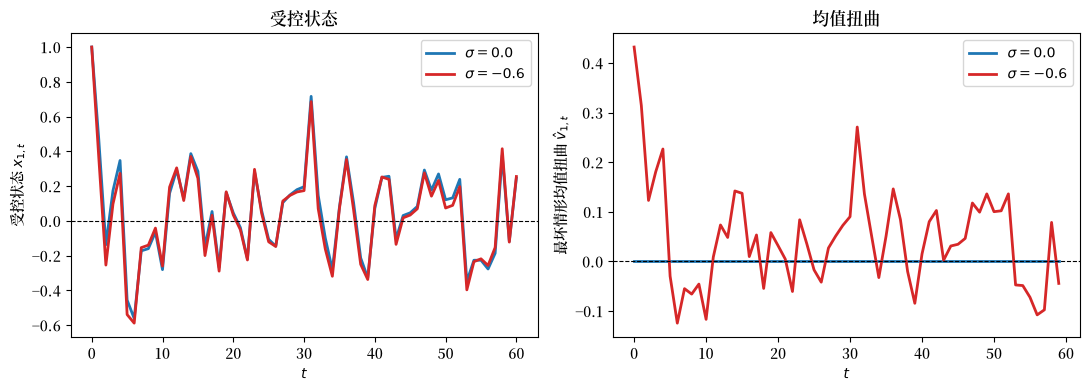

In [10]:
def simulate(A, B, C, F, G, T=60, seed=0):
    rng = np.random.default_rng(seed)
    n, kw = A.shape[0], C.shape[1]
    x = np.zeros((T + 1, n))
    v = np.zeros((T, kw))
    x[0] = np.array([1.0, 1.0])          # 初始偏差
    for t in range(T):
        v[t] = (G @ x[t]).flatten()
        w = rng.standard_normal(kw)
        x[t + 1] = A @ x[t] + (B @ (-F @ x[t])).flatten() + (C @ w).flatten()
    return x, v

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for σ, color in zip([0.0, -0.6], ['C0', 'C3']):
    F, Ω, Acl, G = solve_rslq(A, B, C, Q, R, β, σ)
    x, v = simulate(A, B, C, F, G, seed=42)
    axes[0].plot(x[:, 0], color=color, lw=2, label=f'$\\sigma={σ}$')
    axes[1].plot(v[:, 0], color=color, lw=2, label=f'$\\sigma={σ}$')

axes[0].set_xlabel('$t$')
axes[0].set_ylabel(r'受控状态 $x_{1,t}$')
axes[0].axhline(0, color='k', lw=0.8, ls='--')
axes[0].set_title('受控状态')
axes[0].legend()

axes[1].set_xlabel('$t$')
axes[1].set_ylabel(r'最坏情形均值扭曲 $\hat v_{1,t}$')
axes[1].axhline(0, color='k', lw=0.8, ls='--')
axes[1].set_title('均值扭曲')
axes[1].legend()
fig.tight_layout()
plt.show()

对于 $\sigma = 0$，扭曲恒等于零，因为个体完全信任模型。

对于 $\sigma < 0$，稳健个体的决策受到一个非零的最坏情形扭曲的塑造，该扭曲反馈到状态上，正是通过 {eq}`eq:hst_mpr` 抬高风险市场价格的机制。

## 练习

```{exercise}
:label: hst_ex1

高斯公式 {eq}`eq:hst_R_gauss` 表明，对于 $U_{t+1} \sim N(\mu, s^2)$，

$$
\mathcal{R}_t(U_{t+1}) = \mu + \frac{\sigma}{4} s^2 .
$$

请直接从定义 {eq}`eq:hst_R` 推导这一结果。

*提示：* 使用正态随机变量的矩生成函数，$\mathbb{E}[\exp(a U)] = \exp(a\mu + a^2 s^2 / 2)$。
```

```{solution-start} hst_ex1
:class: dropdown
```

这里是一个解法：

从取 $a = \sigma/2$ 的定义出发：

$$
\mathcal{R}_t(U_{t+1}) = \frac{2}{\sigma} \log \mathbb{E}\!\left[\exp\!\left(\frac{\sigma}{2} U_{t+1}\right)\right].
$$

由于 $U_{t+1} \sim N(\mu, s^2)$，矩生成函数给出

$$
\mathbb{E}\!\left[\exp\!\left(\frac{\sigma}{2} U_{t+1}\right)\right]
= \exp\!\left(\frac{\sigma}{2}\mu + \frac{1}{2}\frac{\sigma^2}{4} s^2\right).
$$

取对数并乘以 $2/\sigma$，

$$
\mathcal{R}_t(U_{t+1})
= \frac{2}{\sigma}\left(\frac{\sigma}{2}\mu + \frac{\sigma^2}{8} s^2\right)
= \mu + \frac{\sigma}{4} s^2 .
$$

令 $\sigma \to 0$ 恢复 $\mathcal{R}_t(U_{t+1}) = \mu = \mathbb{E}_t U_{t+1}$，正如所预期。

```{solution-end}
```

```{exercise}
:label: hst_ex2

观测等价轨迹有一个左端点 $\underline{\sigma}$：使 {eq}`eq:hst_Omega_scalar` 有实数解的最负的 $\sigma$。

使用讲座中的代码，为 `theta2 = 0.01` 和 `theta2 = 0.02` 数值地求出 $\underline{\sigma}$，并解释为什么更大的 $\theta^2$ 会缩小 $\sigma$ 的可容许范围。

*提示：* 当判别式 $(\beta - 1 + \sigma\theta^2)^2 + 4\sigma\theta^2 \geq 0$（在相关的 $\hat\beta$ 处求值）时，平方根为实数。
```

```{solution-start} hst_ex2
:class: dropdown
```

这里是一个解法：

边界 $\underline{\sigma}$ 是仍能找到有效 $\hat\beta$ 的最负的 $\sigma$。

我们向下扫描 $\sigma$，并在 `beta_hat` 不再能返回实数解时停止。

In [11]:
def σ_underbar(θ2, Rf, grid=np.linspace(-1e-6, -5e-4, 5000)):
    last_ok = 0.0
    for sg in grid:
        try:
            b = β_hat(sg, θ2, Rf)
            if np.isnan(Ω_scalar(b, sg, θ2)):
                break
            last_ok = sg
        except ValueError:
            break
    return last_ok

for θ2 in [0.01, 0.02]:
    sb = σ_underbar(θ2, Rf)
    print(f"θ2 = {θ2}:  σ_underbar ≈ {sb:.3e}")

θ2 = 0.01:  σ_underbar ≈ -2.105e-04
θ2 = 0.02:  σ_underbar ≈ -1.052e-04


更大的 $\theta^2$ 意味着边际效用鞅 {eq}`eq:hst_mu_rw` 携带更大的新息方差，因此每单位 $|\sigma|$ 产生更大的风险调整。

{eq}`eq:hst_Omega_scalar` 中的判别式包含 $4\sigma\theta^2 < 0$ 这一项，会在*较小*的 $|\sigma|$ 处变为负值。

因此可容许范围 $(\underline{\sigma}, 0)$ 随 $\theta^2$ 增大而缩小。

```{solution-end}
```

```{exercise}
:label: hst_ex3

风险市场价格近似 {eq}`eq:hst_mpr` 表明
$\operatorname{std}_t(m^u_{t+1,t}) = [\exp(\hat v_t^\top \hat v_t) - 1]^{1/2} \approx |\hat v_t|$。

对于讲座中求解的风险敏感调节者（其中 $A$、$B$、$C$、$Q$、$R$、$\beta$ 如那里给定），计算*精确*的风险市场价格 $[\exp(\hat v_t^\top \hat v_t) - 1]^{1/2}$ 作为 $\sigma$ 的函数，在状态 $x = (1, 1)^\top$ 处求值，并将其与线性近似 $|\hat v_t|$ 一起绘制。

评论该近似准确的 $\sigma$ 范围。
```

```{solution-start} hst_ex3
:class: dropdown
```

这里是一个解法：

我们为一组 $\sigma$ 值求解调节者，在 $x = (1,1)^\top$ 处求值 $\hat v_t = G x$，并比较精确的和近似的风险市场价格。

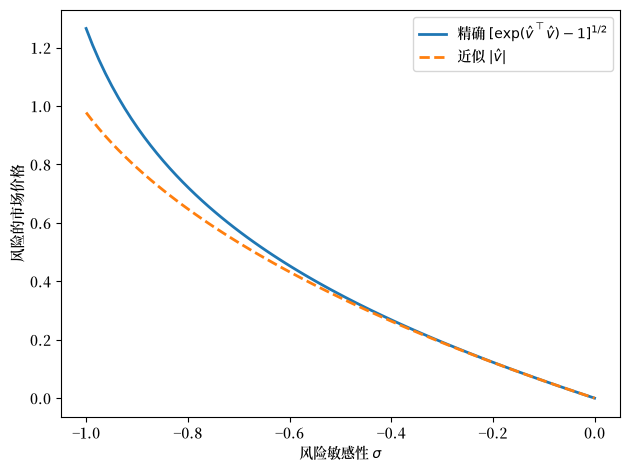

In [12]:
x_eval = np.array([1.0, 1.0])
σ_grid = np.linspace(-1.0, 0.0, 80)

exact, approx = [], []
for σ in σ_grid:
    F, Ω, Acl, G = solve_rslq(A, B, C, Q, R, β, σ)
    v_hat = (G @ x_eval).flatten()
    nv2 = v_hat @ v_hat
    exact.append(np.sqrt(np.exp(nv2) - 1))
    approx.append(np.sqrt(nv2))           # |v_hat|

fig, ax = plt.subplots()
ax.plot(σ_grid, exact, lw=2,
        label=r'精确 $[\exp(\hat v^\top \hat v)-1]^{1/2}$')
ax.plot(σ_grid, approx, lw=2, ls='--', label=r'近似 $|\hat v|$')
ax.set_xlabel(r'风险敏感性 $\sigma$')
ax.set_ylabel('风险的市场价格')
ax.legend()
fig.tight_layout()
plt.show()

对于小的 $|\hat v_t|$（即 $\sigma$ 接近零），这两条曲线几乎无法区分，因为当 $z$ 小时 $\exp(z) - 1 \approx z$。

它们只在对稳健性的偏好、因而最坏情形扭曲变大时才分离。

这正是 {cite:t}`HST_1999` 所强调的情形：*微小*的、难以检测的扭曲几乎线性地映射到风险的市场价格。

```{solution-end}
```

## 相关讲座

本讲座与 QuantEcon 系列中的其他几篇讲座相关联。

底层的消费平滑经济学在 {doc}`perm_income` 和 {doc}`perm_income_cons` 中发展，而线性二次型控制机制在 {doc}`lqcontrol` 中阐述。

将风险的市场价格重新诠释为*模型不确定性的价格*、并通过检测误差概率进行校准，是 {cite:t}`BHS_2009` 的主题；对稳健性、定价和模型检测的更广泛的半群处理在 {cite:t}`AHS_2003` 中。

两者都直接建立在 {cite:t}`HST_1999` 之上。